<a href="https://colab.research.google.com/github/vixiborges/Projeto_fase6/blob/main/GustavoBorges_rm567477_pbl_fase6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Fiap-logo-novo.jpg" width="120"/>
</p>

# 🌾 FarmTech Solutions — Fase 6
## Sistema de Visão Computacional com YOLOv5

| | |
|---|---|
| **Disciplina** | Cognitive Computing & Computer Vision |
| **Fase** | 6 — PBL |
| **Entrega** | 1 — YOLO Customizado |
| **Aluno(s)** | _(Seu Nome)_ — RM XXXXX |
| **Data** | 2025 |

---


## 📑 Índice

1. [Introdução e Contexto](#1)
2. [Configuração do Ambiente](#2)
3. [Montagem do Google Drive](#3)
4. [Organização e Verificação do Dataset](#4)
5. [Instalação do YOLOv5](#5)
6. [Configuração do data.yaml](#6)
7. [Treinamento — 30 Épocas](#7)
8. [Treinamento — 60 Épocas](#8)
9. [Análise Comparativa dos Resultados](#9)
10. [Inferência nas Imagens de Teste](#10)
11. [Conclusões](#11)


---
## 1. Introdução e Contexto <a id='1'></a>

A **FarmTech Solutions** expandiu sua carteira de clientes e agora presta serviços de IA em diversas áreas, incluindo **visão computacional**. Neste projeto, atuamos como o time de desenvolvedores que visita um cliente interessado em entender na prática como funciona um sistema de detecção de objetos.

### Objetivo

Desenvolver um **sistema de visão computacional** baseado em **YOLOv5** capaz de:
- Detectar e classificar dois objetos distintos em imagens
- Comparar o desempenho com diferentes quantidades de épocas de treinamento (30 vs 60)
- Demonstrar acurácia e desempenho ao cliente fictício da FarmTech

### Objetos escolhidos

| Classe | ID | Objeto |
|--------|----|--------|
| **Classe 0** | `garrafa` | Garrafa |
| **Classe 1** | `som` | Caixa de som |

> **Critério de escolha:** os dois objetos possuem formas, texturas e proporções visualmente distintas, favorecendo a separação das classes durante o treinamento.

### Divisão do dataset

| Split | Classe 0 (Garrafa) | Classe 1 (Som) | Total |
|-------|--------------------|----------------|-------|
| Treino | 32 | 32 | 64 |
| Validação | 4 | 4 | 8 |
| Teste | 4 | 4 | 8 |
| **Total** | **40** | **40** | **80** |

### Rotulação

As imagens de treino e validação foram rotuladas manualmente com **bounding boxes** usando o **[Make Sense IA](https://www.makesense.ai/)**, exportadas no **formato YOLO** (`.txt` com coordenadas normalizadas).


---
## 2. Configuração do Ambiente <a id='2'></a>

Verificamos a GPU disponível no Colab e as versões das principais bibliotecas antes de iniciar o pipeline.


In [1]:
# Verificar GPU disponível no Colab
# Acesse: Runtime > Change runtime type > Hardware accelerator > GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
else:
    print("⚠️  GPU não detectada. Vá em Runtime > Change runtime type > GPU.")


Thu Apr 30 01:40:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Versão do Python e informações do sistema
import sys, os, platform
print(f"Python : {sys.version}")
print(f"Sistema: {platform.system()} {platform.release()}")
print(f"Diretório atual: {os.getcwd()}")


Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Sistema: Linux 6.6.113+
Diretório atual: /content


---
## 3. Montagem do Google Drive <a id='3'></a>

Todo o dataset, configurações e resultados ficam armazenados no Google Drive, garantindo
persistência entre sessões do Colab. A pasta do projeto é **`projeto_fase6`**.


In [3]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive montado com sucesso!")


Mounted at /content/drive
✅ Google Drive montado com sucesso!


In [4]:
# ── CAMINHO BASE DO PROJETO ──────────────────────────────────────────────────
# Pasta raiz do projeto no Drive — sem espaços para evitar erros de shell
DRIVE_BASE = '/content/drive/MyDrive/projeto_fase6'

# Verificar se a pasta existe
import os
if os.path.exists(DRIVE_BASE):
    print(f"✅ Pasta do projeto encontrada: {DRIVE_BASE}")
    for item in sorted(os.listdir(DRIVE_BASE)):
        print(f"   ├── {item}")
else:
    print(f"❌ Pasta não encontrada: {DRIVE_BASE}")
    print("   Crie a estrutura de pastas conforme o README antes de continuar.")


✅ Pasta do projeto encontrada: /content/drive/MyDrive/projeto_fase6
   ├── assets_amostra_treino.png
   ├── comparativo_30_60_epocas.png
   ├── dataset
   ├── metricas_30ep.png
   ├── metricas_60ep.png
   ├── results


---
## 4. Organização e Verificação do Dataset <a id='4'></a>

### Estrutura esperada no Google Drive

```
projeto_fase6/
├── dataset/
│   ├── images/
│   │   ├── train/     ← 64 imagens (32 Garrafa + 32 Som)
│   │   ├── val/       ← 8 imagens  (4 Garrafa + 4 Som)
│   │   └── test/      ← 8 imagens  (4 Garrafa + 4 Som)
│   └── labels/
│       ├── train/     ← 64 arquivos .txt no formato YOLO
│       └── val/       ← 8 arquivos .txt
└── data.yaml
```

### Formato dos labels YOLO
Cada linha de um `.txt` representa um objeto anotado:
```
<class_id>  <x_center>  <y_center>  <width>  <height>
```
Todos os valores são normalizados entre 0 e 1 em relação às dimensões da imagem.


In [5]:
# Verificar estrutura e contar imagens/labels por split
import os

DATASET_PATH = os.path.join(DRIVE_BASE, 'dataset')

for split in ['train', 'val', 'test']:
    img_dir = os.path.join(DATASET_PATH, 'images', split)
    lbl_dir = os.path.join(DATASET_PATH, 'labels', split)

    imgs = []
    lbls = []

    if os.path.exists(img_dir):
        imgs = [f for f in os.listdir(img_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if os.path.exists(lbl_dir):
        lbls = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]

    status = "✅" if len(imgs) > 0 else "⚠️ "
    print(f"{status} {split:8s} → {len(imgs):3d} imagens | {len(lbls):3d} labels")
    if imgs:
        print(f"           Arquivos: {sorted(imgs)}")


✅ train    →  64 imagens |  64 labels
           Arquivos: ['Garrafa_01.jpg', 'Garrafa_02.jpg', 'Garrafa_03.jpg', 'Garrafa_04.jpg', 'Garrafa_05.jpg', 'Garrafa_06.jpg', 'Garrafa_07.jpg', 'Garrafa_08.jpg', 'Garrafa_09.jpg', 'Garrafa_10.jpg', 'Garrafa_11.jpg', 'Garrafa_12.jpg', 'Garrafa_13.jpg', 'Garrafa_14.jpg', 'Garrafa_15.jpg', 'Garrafa_16.jpg', 'Garrafa_17.jpg', 'Garrafa_18.jpg', 'Garrafa_19.jpg', 'Garrafa_20.jpg', 'Garrafa_21.jpg', 'Garrafa_22.jpg', 'Garrafa_23.jpg', 'Garrafa_24.jpg', 'Garrafa_25.jpg', 'Garrafa_26.jpg', 'Garrafa_27.jpg', 'Garrafa_28.jpg', 'Garrafa_29.jpg', 'Garrafa_30.jpg', 'Garrafa_31.jpg', 'Garrafa_32.jpg', 'Som_01.jpg', 'Som_02.jpg', 'Som_03.jpg', 'Som_04.jpg', 'Som_05.jpg', 'Som_06.jpg', 'Som_07.jpg', 'Som_08.jpg', 'Som_09.jpg', 'Som_10.jpg', 'Som_11.jpg', 'Som_12.jpg', 'Som_13.jpg', 'Som_14.jpg', 'Som_15.jpg', 'Som_16.jpg', 'Som_17.jpg', 'Som_18.jpg', 'Som_19.jpg', 'Som_20.jpg', 'Som_21.jpg', 'Som_22.jpg', 'Som_23.jpg', 'Som_24.jpg', 'Som_25.jpg', 'Som_26.jpg', 

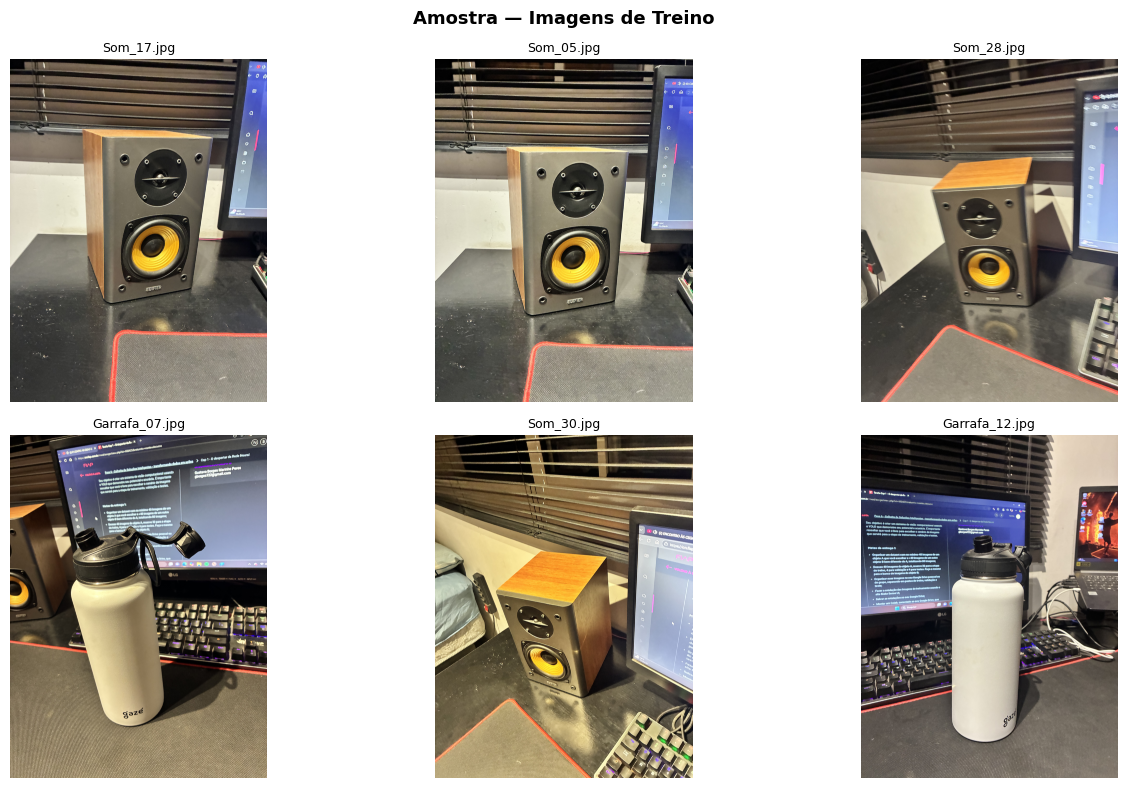

✅ Amostra salva em: /content/drive/MyDrive/projeto_fase6/amostra_treino.png


In [6]:
# Visualizar amostra de imagens do dataset de treino
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os, random

img_dir = os.path.join(DATASET_PATH, 'images', 'train')
imgs    = [f for f in os.listdir(img_dir)
           if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample  = random.sample(imgs, min(6, len(imgs)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Amostra — Imagens de Treino', fontsize=13, fontweight='bold')

for ax, fname in zip(axes.flatten(), sample):
    img = mpimg.imread(os.path.join(img_dir, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=9)
    ax.axis('off')

for ax in axes.flatten()[len(sample):]:
    ax.axis('off')

plt.tight_layout()

# Salvar localmente e copiar para o Drive (evita erro com espaços no path)
local_path = '/content/amostra_treino.png'
drive_path = os.path.join(DRIVE_BASE, 'amostra_treino.png')
plt.savefig(local_path, dpi=100, bbox_inches='tight')
import shutil; shutil.copy(local_path, drive_path)
plt.show()
print(f"✅ Amostra salva em: {drive_path}")


---
## 5. Instalação do YOLOv5 <a id='5'></a>

Clonamos o repositório oficial da Ultralytics e instalamos as dependências. Essa etapa
só precisa ser executada uma vez por sessão do Colab.


In [7]:
# Clonar YOLOv5 (pula se já existir)
import os

if not os.path.exists('/content/yolov5'):
    os.system('git clone https://github.com/ultralytics/yolov5')
    print("✅ YOLOv5 clonado!")
else:
    print("ℹ️  YOLOv5 já presente — pulando clonagem.")

os.chdir('/content/yolov5')
print(f"📁 Diretório atual: {os.getcwd()}")


✅ YOLOv5 clonado!
📁 Diretório atual: /content/yolov5


In [8]:
# Instalar dependências do YOLOv5
import subprocess

result = subprocess.run(
    ['pip', 'install', '-r', 'requirements.txt', '-q'],
    capture_output=True, text=True
)
print("✅ Dependências instaladas!" if result.returncode == 0
      else f"❌ Erro:\n{result.stderr[:500]}")


✅ Dependências instaladas!


In [9]:
# Confirmar versões das bibliotecas principais
import torch, torchvision, cv2

print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"CUDA ativo  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
OpenCV      : 4.13.0
CUDA ativo  : True
GPU         : Tesla T4
VRAM        : 15.6 GB


---
## 6. Configuração do `data.yaml` <a id='6'></a>

O `data.yaml` informa ao YOLOv5 os caminhos do dataset e os nomes das classes.
A ordem de `names` deve ser idêntica à ordem usada na rotulação do Make Sense IA
(Classe 0 = Garrafa, Classe 1 = Som).


In [10]:
# Gerar data.yaml automaticamente e salvar no diretório do YOLOv5
import yaml, os

DATASET_PATH = os.path.join(DRIVE_BASE, 'dataset')

# ⚠️ A ordem de CLASS_NAMES deve bater com os IDs usados no Make Sense IA
CLASS_NAMES = ['garrafa', 'som']

data_config = {
    'path' : DATASET_PATH,
    'train': os.path.join(DATASET_PATH, 'images', 'train'),
    'val'  : os.path.join(DATASET_PATH, 'images', 'val'),
    'test' : os.path.join(DATASET_PATH, 'images', 'test'),
    'nc'   : len(CLASS_NAMES),
    'names': CLASS_NAMES
}

yaml_path = '/content/yolov5/data/farmtech_fase6.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print(f"✅ data.yaml salvo em: {yaml_path}")
print("\nConteúdo gerado:")
print("-" * 45)
with open(yaml_path) as f:
    print(f.read())


✅ data.yaml salvo em: /content/yolov5/data/farmtech_fase6.yaml

Conteúdo gerado:
---------------------------------------------
names:
- garrafa
- som
nc: 2
path: /content/drive/MyDrive/projeto_fase6/dataset
test: /content/drive/MyDrive/projeto_fase6/dataset/images/test
train: /content/drive/MyDrive/projeto_fase6/dataset/images/train
val: /content/drive/MyDrive/projeto_fase6/dataset/images/val



---
## 7. Treinamento — 30 Épocas <a id='7'></a>

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Motivo |
|-----------|-------|--------|
| `--epochs` | 30 | Baseline rápido para comparação |
| `--batch` | 16 | Equilibrio entre velocidade e estabilidade do gradiente |
| `--img` | 640 | Resolução padrão do YOLOv5 |
| `--weights` | yolov5s.pt | Modelo pré-treinado (small) — transfer learning |
| `--name` | exp_30ep | Identificador único do experimento |

O uso de `yolov5s.pt` aplica **transfer learning**: o modelo já conhece
características visuais gerais (bordas, formas, texturas) e só precisa
adaptar os pesos para nossas classes específicas.


In [11]:
# ── TREINAMENTO: 30 ÉPOCAS ───────────────────────────────────────────────────
import os, subprocess, time

os.chdir('/content/yolov5')

print("🚀 Iniciando treinamento — 30 épocas...")
print("=" * 60)

start = time.time()

result = subprocess.run(
    [
        'python', 'train.py',
        '--img',     '640',
        '--batch',   '16',
        '--epochs',  '30',
        '--data',    'data/farmtech_fase6.yaml',
        '--weights', 'yolov5s.pt',
        '--name',    'exp_30ep',
        '--cache',
        '--exist-ok'
    ],
    capture_output=True, text=True
)

elapsed = (time.time() - start) / 60
print(result.stdout[-4000:])
if result.stderr:
    print("STDERR:", result.stderr[-500:])

print("=" * 60)
if result.returncode == 0:
    print(f"✅ Treinamento de 30 épocas concluído em {elapsed:.1f} min!")
    print("📊 Resultados em: runs/train/exp_30ep/")
else:
    print(f"❌ Erro no treinamento (código {result.returncode})")


🚀 Iniciando treinamento — 30 épocas...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

STDERR: 0-95: 100%|██████████| 1/1 [00:00<00:00,  9.25it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 1/1 [00:00<00:00,  9.22it/s]
                   all          8          8      0.962          1      0.995      0.683
               garrafa          8          4      0.929          1      0.995      0.578
                   som          8          4      0.995          1      0.995      0.787
Results saved to runs/train/exp_30ep

✅ Treinamento de 30 épocas concluído em 8.0 min!
📊 Resultados em: runs/train/exp_30ep/


📊 Painel de métricas — 30 épocas:


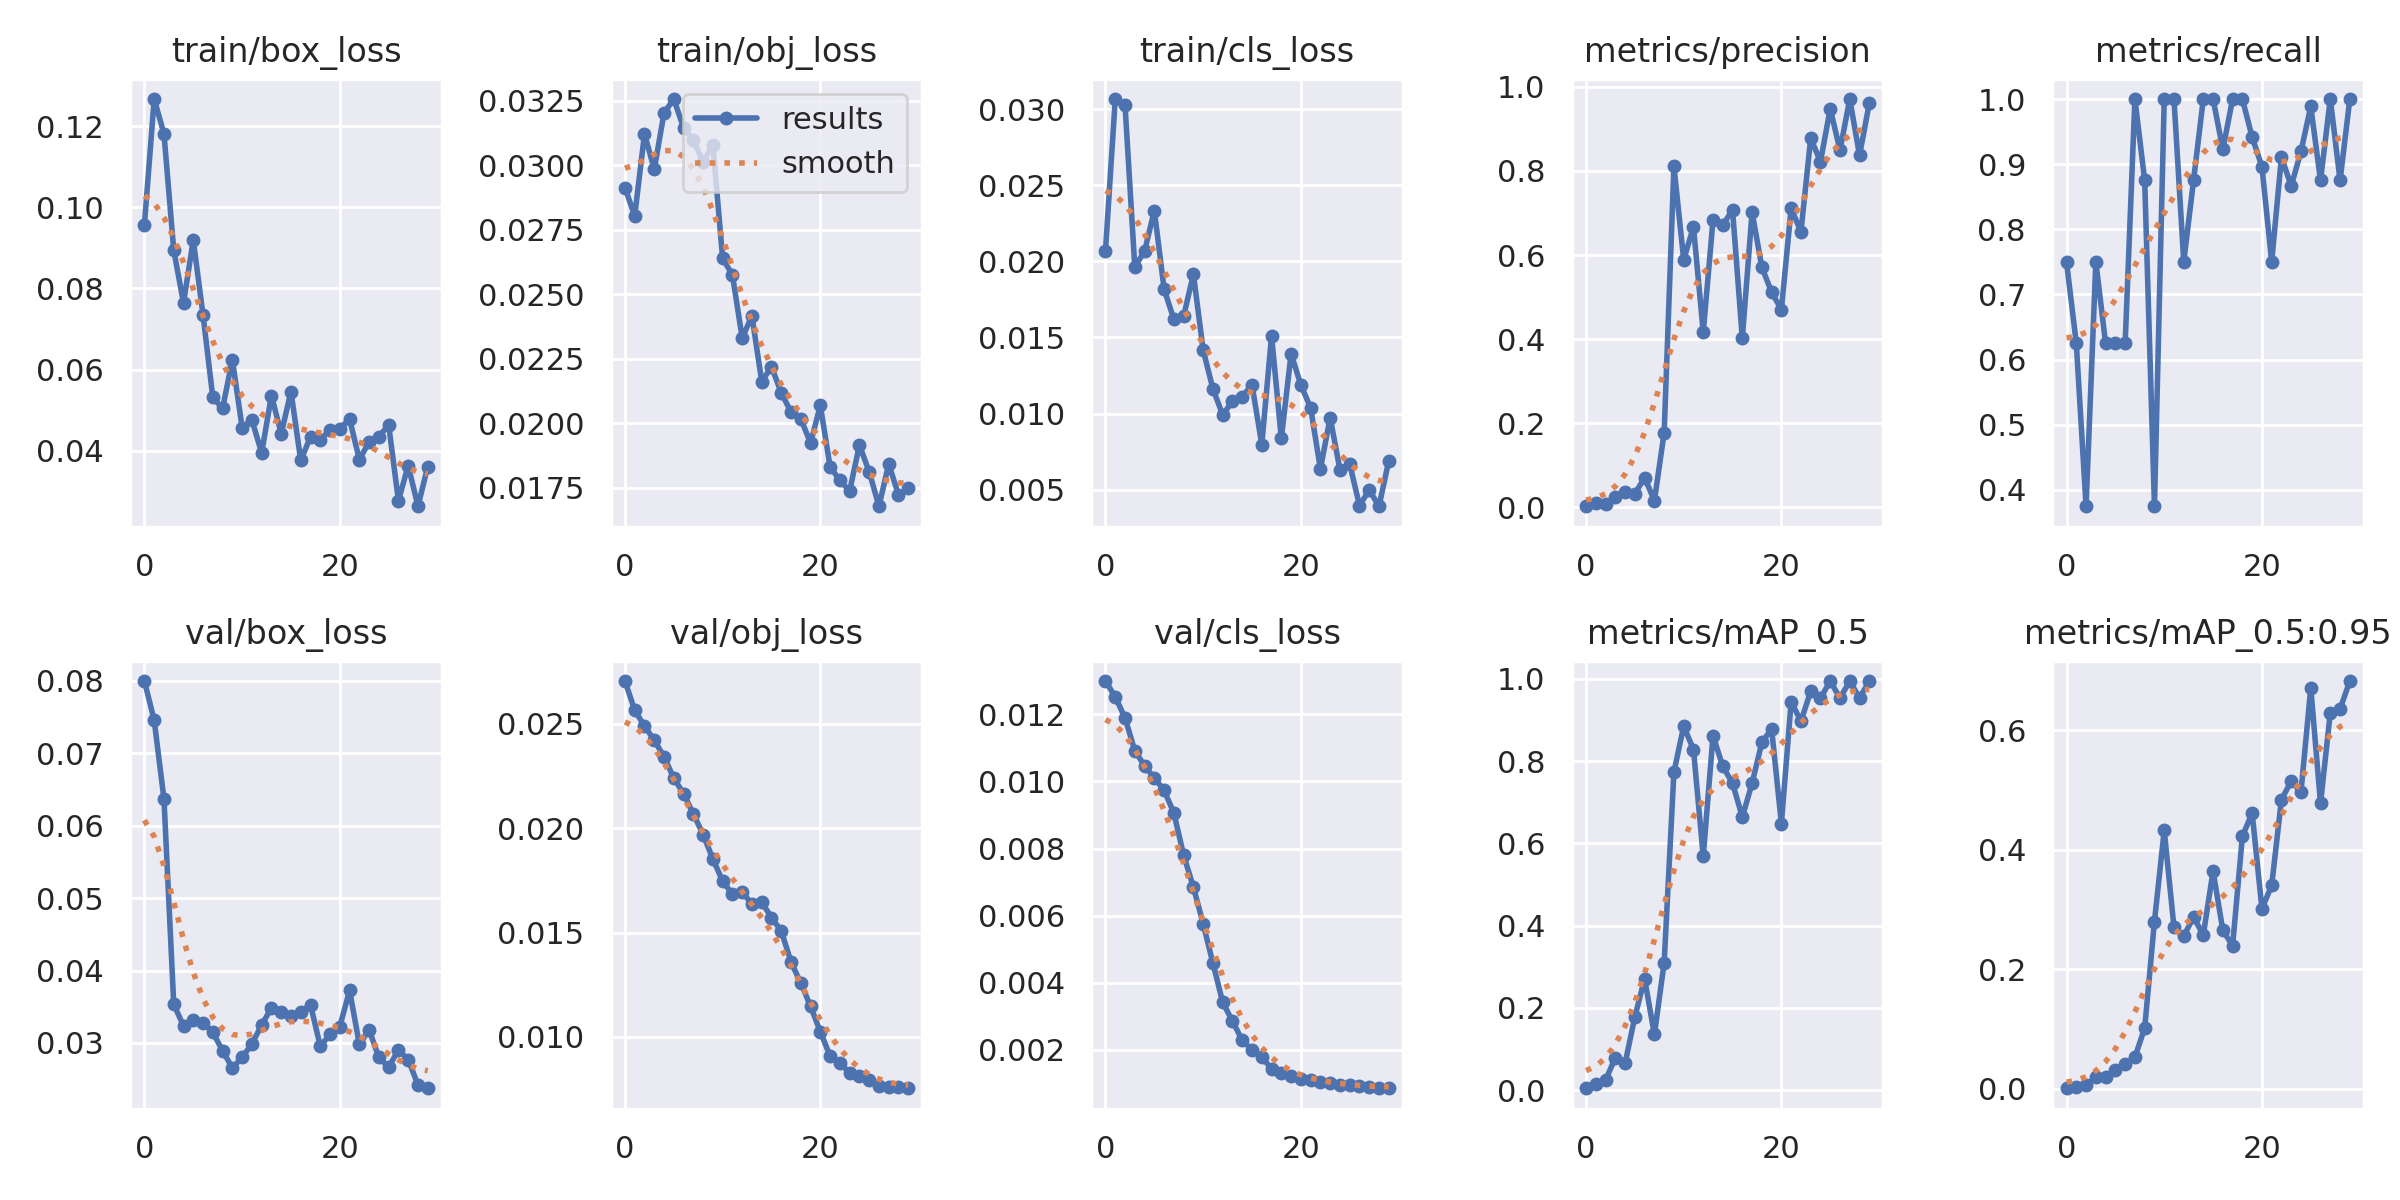

In [12]:
# Exibir painel de métricas gerado automaticamente pelo YOLOv5 (30 épocas)
from IPython.display import Image, display
import os

results_img = '/content/yolov5/runs/train/exp_30ep/results.png'
if os.path.exists(results_img):
    print("📊 Painel de métricas — 30 épocas:")
    display(Image(results_img, width=900))
else:
    print("❌ results.png não encontrado — verifique se o treino concluiu.")


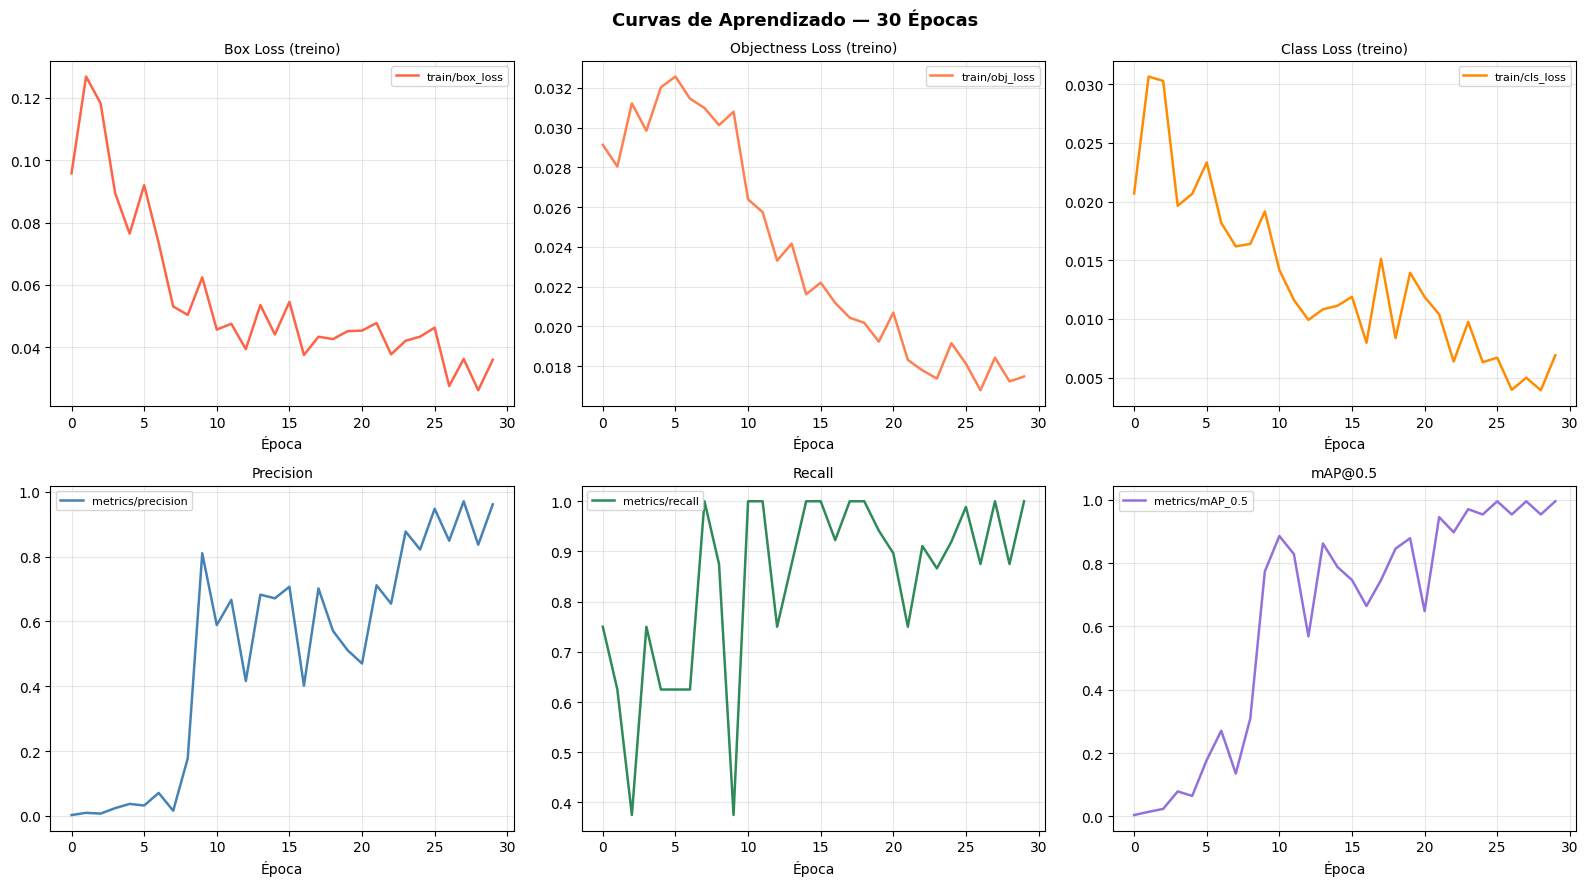

✅ Gráfico salvo no Drive.

Últimas 5 épocas:
    epoch  train/box_loss  train/obj_loss  train/cls_loss  metrics/precision  metrics/recall  metrics/mAP_0.5  metrics/mAP_0.5:0.95  val/box_loss  val/obj_loss  val/cls_loss    x/lr0    x/lr1    x/lr2
25     25        0.046316        0.018129        0.006692            0.94771         0.98856          0.99500               0.67121      0.026659      0.007966      0.000969  0.00175  0.00175  0.00175
26     26        0.027615        0.016791        0.003956            0.84927         0.87500          0.95333               0.47807      0.029043      0.007646      0.000924  0.00175  0.00175  0.00175
27     27        0.036279        0.018428        0.004984            0.97093         1.00000          0.99500               0.62966      0.027690      0.007602      0.000908  0.00142  0.00142  0.00142
28     28        0.026247        0.017237        0.003914            0.83678         0.87500          0.95333               0.63592      0.024221      

In [13]:
# Plotar curvas de aprendizado — 30 épocas (a partir do results.csv)
import pandas as pd
import matplotlib.pyplot as plt
import os

results_path = '/content/yolov5/runs/train/exp_30ep/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    metricas = {
        'train/box_loss' : ('Box Loss (treino)',       'tomato'),
        'train/obj_loss' : ('Objectness Loss (treino)','coral'),
        'train/cls_loss' : ('Class Loss (treino)',     'darkorange'),
        'metrics/precision': ('Precision',             'steelblue'),
        'metrics/recall'   : ('Recall',                'seagreen'),
        'metrics/mAP_0.5'  : ('mAP@0.5',              'mediumpurple'),
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Curvas de Aprendizado — 30 Épocas', fontsize=13, fontweight='bold')

    for ax, (col, (titulo, cor)) in zip(axes.flatten(), metricas.items()):
        if col in df.columns:
            ax.plot(df[col], color=cor, linewidth=1.8, label=col)
            ax.set_title(titulo, fontsize=10)
            ax.set_xlabel('Época')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, f'{col}\nnão encontrada',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='gray')
            ax.set_title(titulo, fontsize=10)

    plt.tight_layout()
    local_path = '/content/metricas_30ep.png'
    plt.savefig(local_path, dpi=120, bbox_inches='tight')
    import shutil
    shutil.copy(local_path, os.path.join(DRIVE_BASE, 'metricas_30ep.png'))
    plt.show()
    print("✅ Gráfico salvo no Drive.")

    # Imprimir últimas 5 épocas
    print("\nÚltimas 5 épocas:")
    print(df.tail(5).to_string())
else:
    print("❌ results.csv não encontrado.")


---
## 8. Treinamento — 60 Épocas <a id='8'></a>

Dobramos o número de épocas mantendo todos os demais hiperparâmetros iguais,
de forma a isolar o efeito exclusivo da quantidade de épocas sobre as métricas.

**Hipótese:** com mais iterações sobre o dataset, o modelo deve ajustar os
pesos com maior precisão — porém, com um dataset pequeno (64 imagens de treino),
há risco de **overfitting**, detectável quando a `val_loss` sobe enquanto a
`train_loss` continua caindo.


In [14]:
# ── TREINAMENTO: 60 ÉPOCAS ───────────────────────────────────────────────────
import os, subprocess, time

os.chdir('/content/yolov5')

print("🚀 Iniciando treinamento — 60 épocas...")
print("=" * 60)

start = time.time()

result = subprocess.run(
    [
        'python', 'train.py',
        '--img',     '640',
        '--batch',   '16',
        '--epochs',  '60',
        '--data',    'data/farmtech_fase6.yaml',
        '--weights', 'yolov5s.pt',
        '--name',    'exp_60ep',
        '--cache',
        '--exist-ok'
    ],
    capture_output=True, text=True
)

elapsed = (time.time() - start) / 60
print(result.stdout[-4000:])
if result.stderr:
    print("STDERR:", result.stderr[-500:])

print("=" * 60)
if result.returncode == 0:
    print(f"✅ Treinamento de 60 épocas concluído em {elapsed:.1f} min!")
    print("📊 Resultados em: runs/train/exp_60ep/")
else:
    print(f"❌ Erro no treinamento (código {result.returncode})")


🚀 Iniciando treinamento — 60 épocas...

STDERR: 0   mAP50-95:   0%|          | 0/1 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 1/1 [00:00<00:00, 11.15it/s]
                   all          8          8      0.983          1      0.995      0.774
               garrafa          8          4      0.987          1      0.995      0.709
                   som          8          4      0.979          1      0.995      0.839
Results saved to runs/train/exp_60ep

✅ Treinamento de 60 épocas concluído em 2.6 min!
📊 Resultados em: runs/train/exp_60ep/


📊 Painel de métricas — 60 épocas:


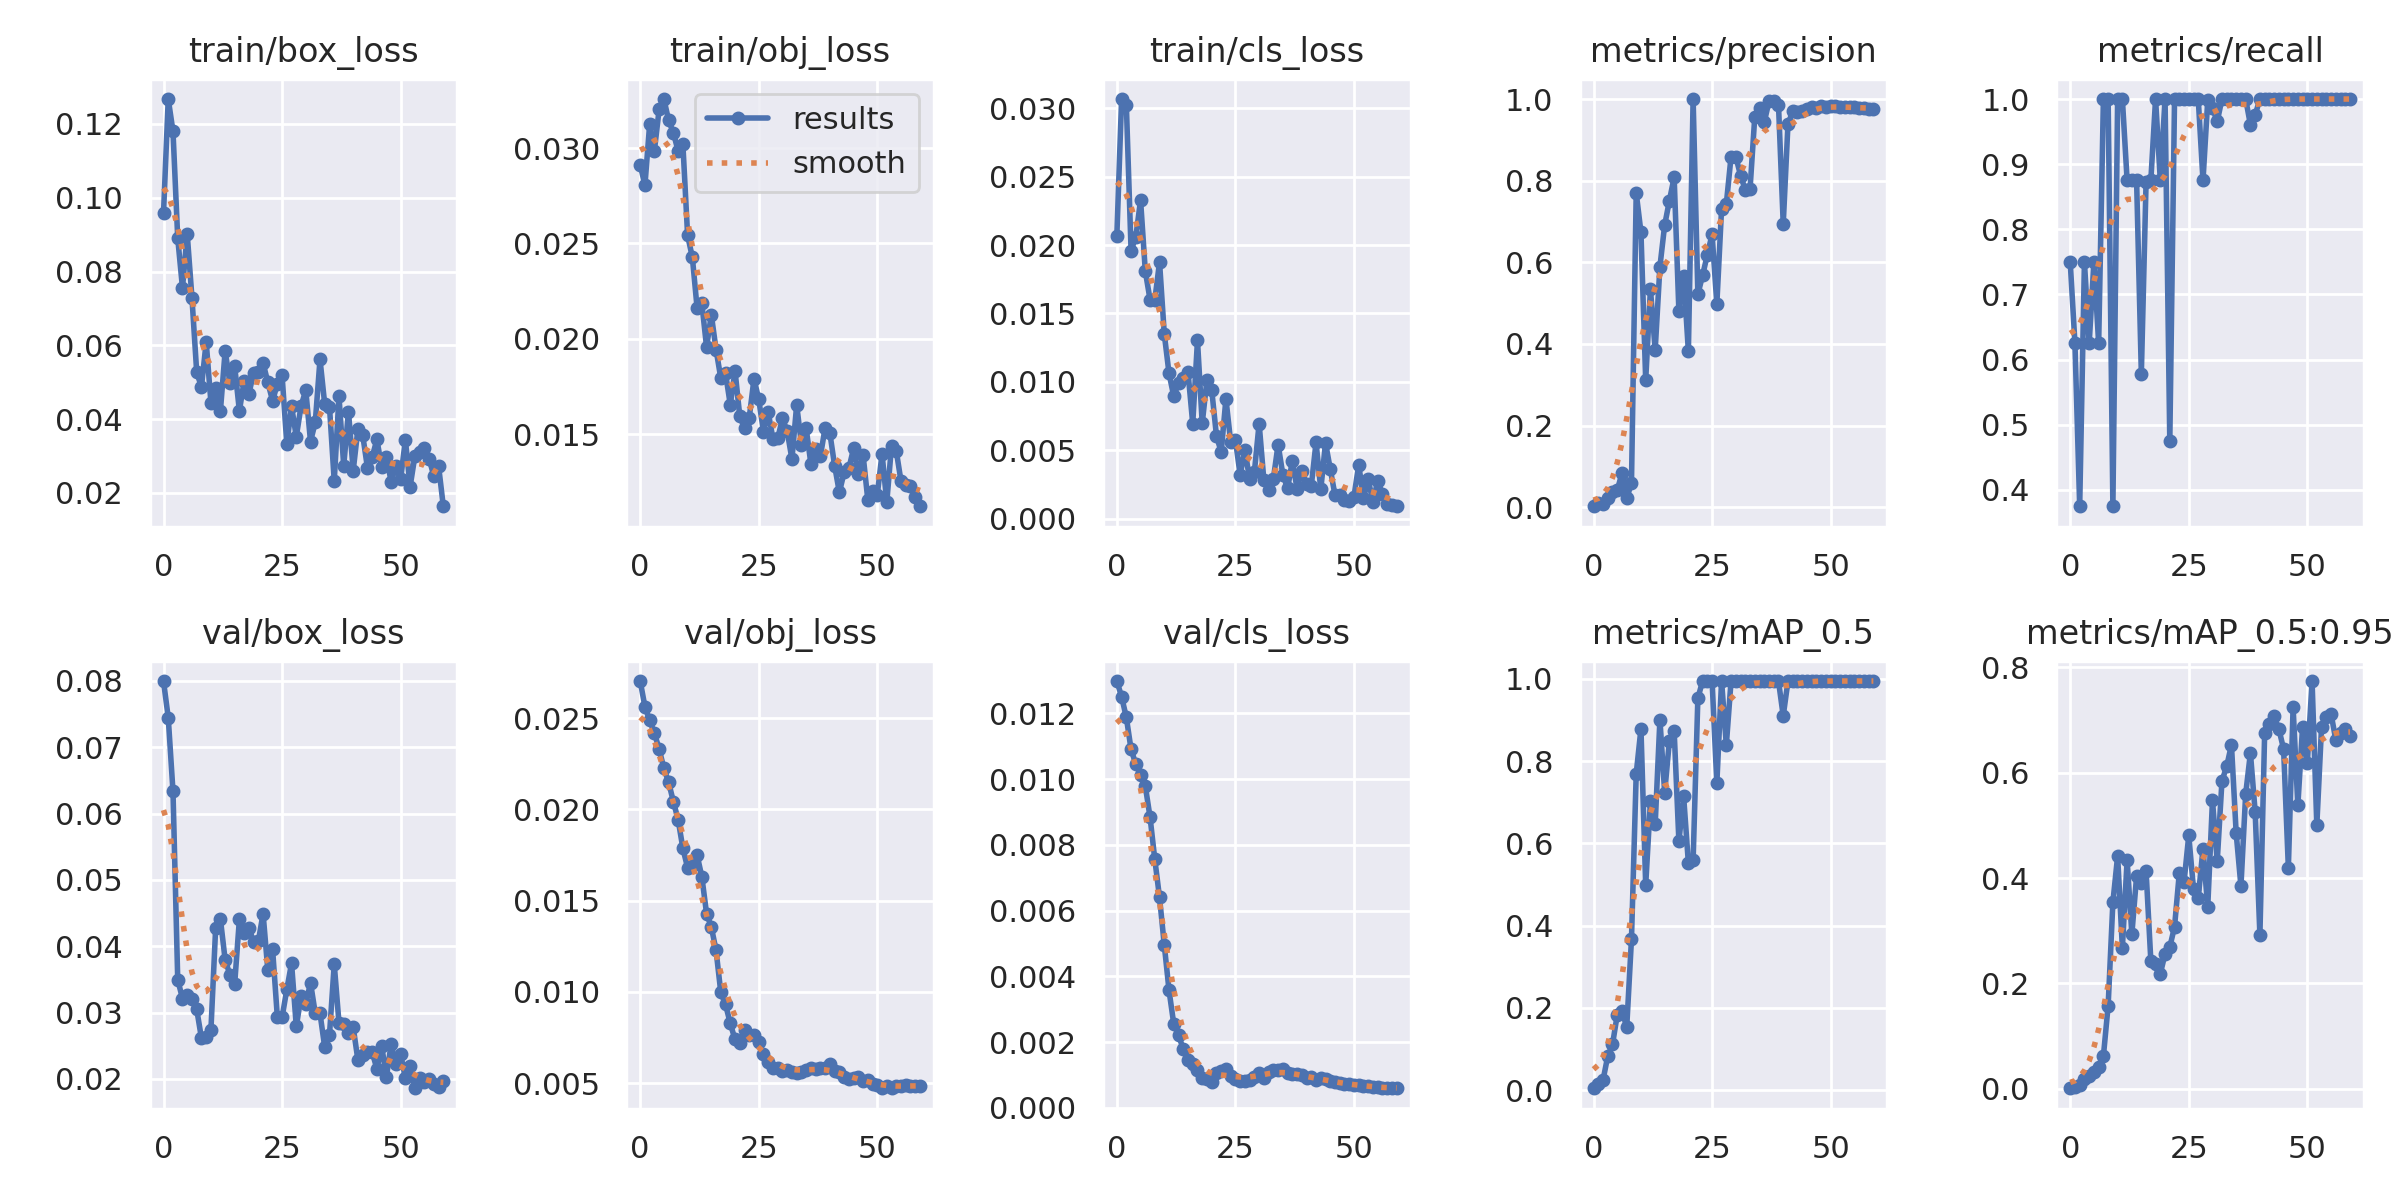

In [15]:
# Exibir painel de métricas — 60 épocas
from IPython.display import Image, display
import os

results_img = '/content/yolov5/runs/train/exp_60ep/results.png'
if os.path.exists(results_img):
    print("📊 Painel de métricas — 60 épocas:")
    display(Image(results_img, width=900))
else:
    print("❌ results.png não encontrado.")


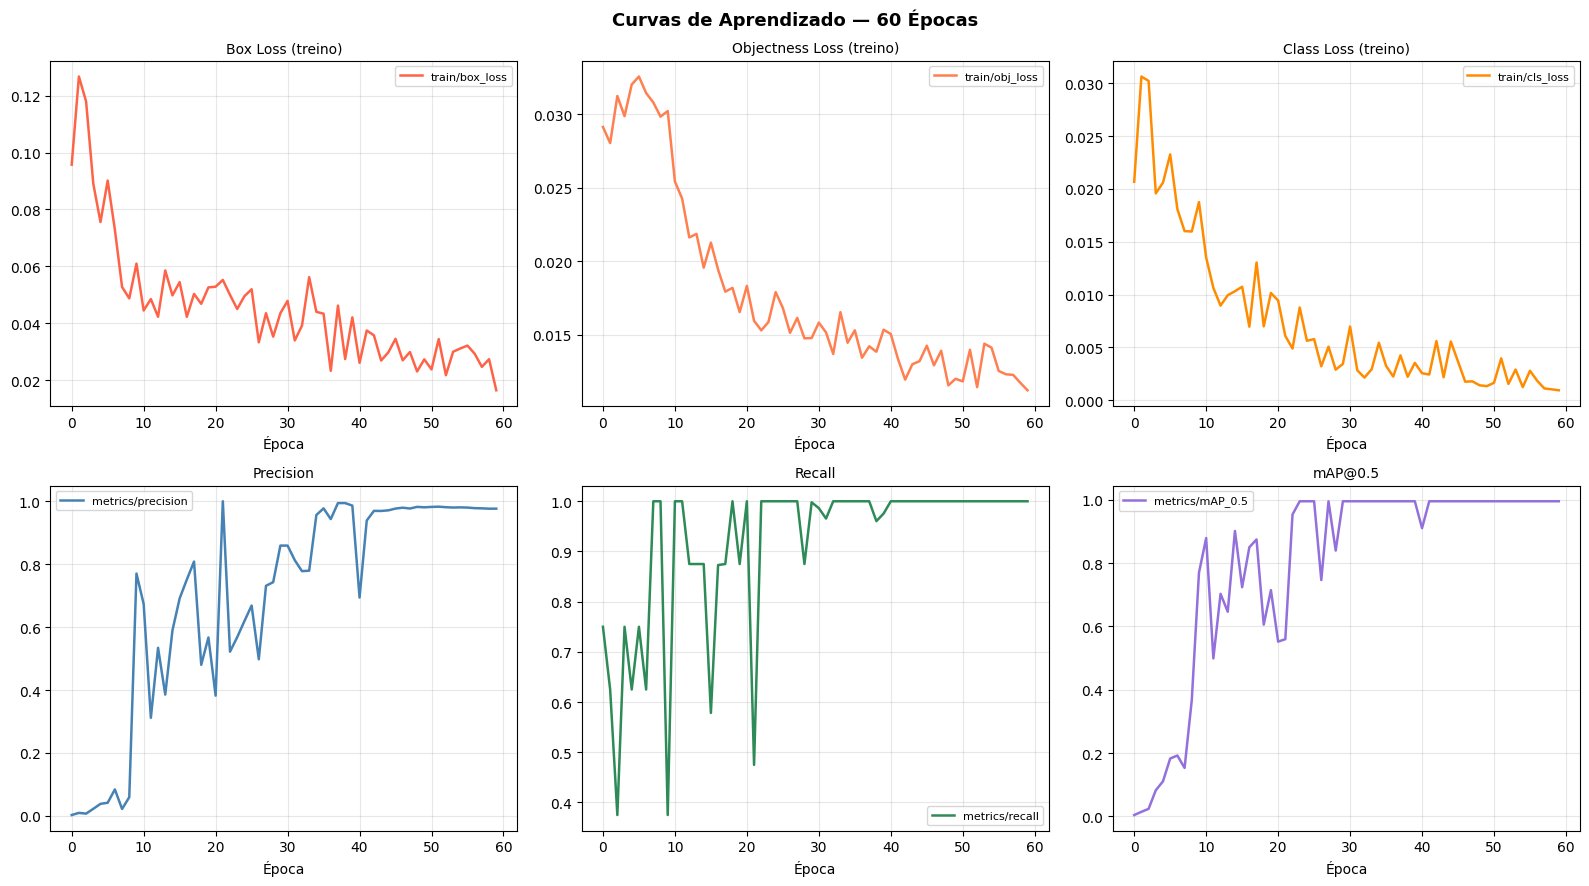

✅ Gráfico salvo no Drive.

Últimas 5 épocas:
    epoch  train/box_loss  train/obj_loss  train/cls_loss  metrics/precision  metrics/recall  metrics/mAP_0.5  metrics/mAP_0.5:0.95  val/box_loss  val/obj_loss  val/cls_loss     x/lr0     x/lr1     x/lr2
55     55        0.032117        0.012543        0.002775            0.97999             1.0            0.995               0.71194      0.019598      0.004829      0.000618  0.001090  0.001090  0.001090
56     56        0.029260        0.012318        0.001825            0.97808             1.0            0.995               0.66219      0.020065      0.004874      0.000608  0.000925  0.000925  0.000925
57     57        0.024644        0.012279        0.001095            0.97755             1.0            0.995               0.67468      0.019176      0.004852      0.000594  0.000760  0.000760  0.000760
58     58        0.027335        0.011740        0.001015            0.97639             1.0            0.995               0.68293      0.

In [16]:
# Plotar curvas de aprendizado — 60 épocas
import pandas as pd
import matplotlib.pyplot as plt
import shutil, os

results_path = '/content/yolov5/runs/train/exp_60ep/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    metricas = {
        'train/box_loss'   : ('Box Loss (treino)',        'tomato'),
        'train/obj_loss'   : ('Objectness Loss (treino)', 'coral'),
        'train/cls_loss'   : ('Class Loss (treino)',      'darkorange'),
        'metrics/precision': ('Precision',                'steelblue'),
        'metrics/recall'   : ('Recall',                   'seagreen'),
        'metrics/mAP_0.5'  : ('mAP@0.5',                 'mediumpurple'),
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Curvas de Aprendizado — 60 Épocas', fontsize=13, fontweight='bold')

    for ax, (col, (titulo, cor)) in zip(axes.flatten(), metricas.items()):
        if col in df.columns:
            ax.plot(df[col], color=cor, linewidth=1.8, label=col)
            ax.set_title(titulo, fontsize=10)
            ax.set_xlabel('Época')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, f'{col}\nnão encontrada',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='gray')
            ax.set_title(titulo, fontsize=10)

    plt.tight_layout()
    local_path = '/content/metricas_60ep.png'
    plt.savefig(local_path, dpi=120, bbox_inches='tight')
    shutil.copy(local_path, os.path.join(DRIVE_BASE, 'metricas_60ep.png'))
    plt.show()
    print("✅ Gráfico salvo no Drive.")

    print("\nÚltimas 5 épocas:")
    print(df.tail(5).to_string())
else:
    print("❌ results.csv não encontrado.")


---
## 9. Análise Comparativa dos Resultados <a id='9'></a>

Comparamos as duas configurações de treinamento nas principais métricas do YOLOv5:

| Métrica | Significado |
|---------|-------------|
| **mAP@0.5** | Mean Average Precision com IoU ≥ 50% — principal métrica de detecção |
| **Precision** | Das detecções feitas, quantas % estavam corretas |
| **Recall** | Dos objetos reais, quantos % o modelo encontrou |
| **Box Loss** | Erro de localização do bounding box (menor = melhor) |
| **Tempo** | Custo computacional de cada configuração |


In [17]:
# ── TABELA COMPARATIVA — última época de cada treino ─────────────────────────
import pandas as pd
import os

def ler_ultima_epoca(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df.iloc[-1]

ep30 = ler_ultima_epoca('/content/yolov5/runs/train/exp_30ep/results.csv')
ep60 = ler_ultima_epoca('/content/yolov5/runs/train/exp_60ep/results.csv')

if ep30 is not None and ep60 is not None:
    colunas = [
        ('metrics/precision',    'Precision',     '%',  True),
        ('metrics/recall',       'Recall',        '%',  True),
        ('metrics/mAP_0.5',      'mAP@0.5',       '%',  True),
        ('metrics/mAP_0.5:0.95', 'mAP@0.5:0.95', '%',  True),
        ('train/box_loss',       'Box Loss',       '',   False),
        ('train/obj_loss',       'Obj Loss',       '',   False),
        ('train/cls_loss',       'Cls Loss',       '',   False),
    ]

    rows = []
    for col, nome, unidade, maior_melhor in colunas:
        if col in ep30.index and col in ep60.index:
            v30, v60 = ep30[col], ep60[col]
            delta = v60 - v30
            # Seta indica melhora real (não só diferença)
            melhorou = delta > 0 if maior_melhor else delta < 0
            seta = '↑' if melhorou else ('↓' if delta != 0 else '=')
            rows.append({
                'Métrica'    : nome,
                '30 Épocas'  : f'{v30:.4f}{unidade}',
                '60 Épocas'  : f'{v60:.4f}{unidade}',
                'Δ (60−30)'  : f'{delta:+.4f}{unidade} {seta}',
                'Melhor'     : '60 ep' if melhorou else ('30 ep' if not melhorou and delta != 0 else 'Empate'),
            })

    tabela = pd.DataFrame(rows)
    print("=" * 72)
    print("         COMPARATIVO FINAL: 30 ÉPOCAS × 60 ÉPOCAS")
    print("=" * 72)
    print(tabela.to_string(index=False))
    print("=" * 72)
else:
    print("⚠️  Execute as células de treinamento antes desta.")


         COMPARATIVO FINAL: 30 ÉPOCAS × 60 ÉPOCAS
     Métrica 30 Épocas 60 Épocas  Δ (60−30) Melhor
   Precision   0.9613%   0.9765% +0.0152% ↑  60 ep
      Recall   1.0000%   1.0000% +0.0000% = Empate
     mAP@0.5   0.9950%   0.9950% +0.0000% = Empate
mAP@0.5:0.95   0.6827%   0.6705% -0.0122% ↓  30 ep
    Box Loss    0.0360    0.0164  -0.0196 ↑  60 ep
    Obj Loss    0.0175    0.0112  -0.0063 ↑  60 ep
    Cls Loss    0.0069    0.0009  -0.0060 ↑  60 ep


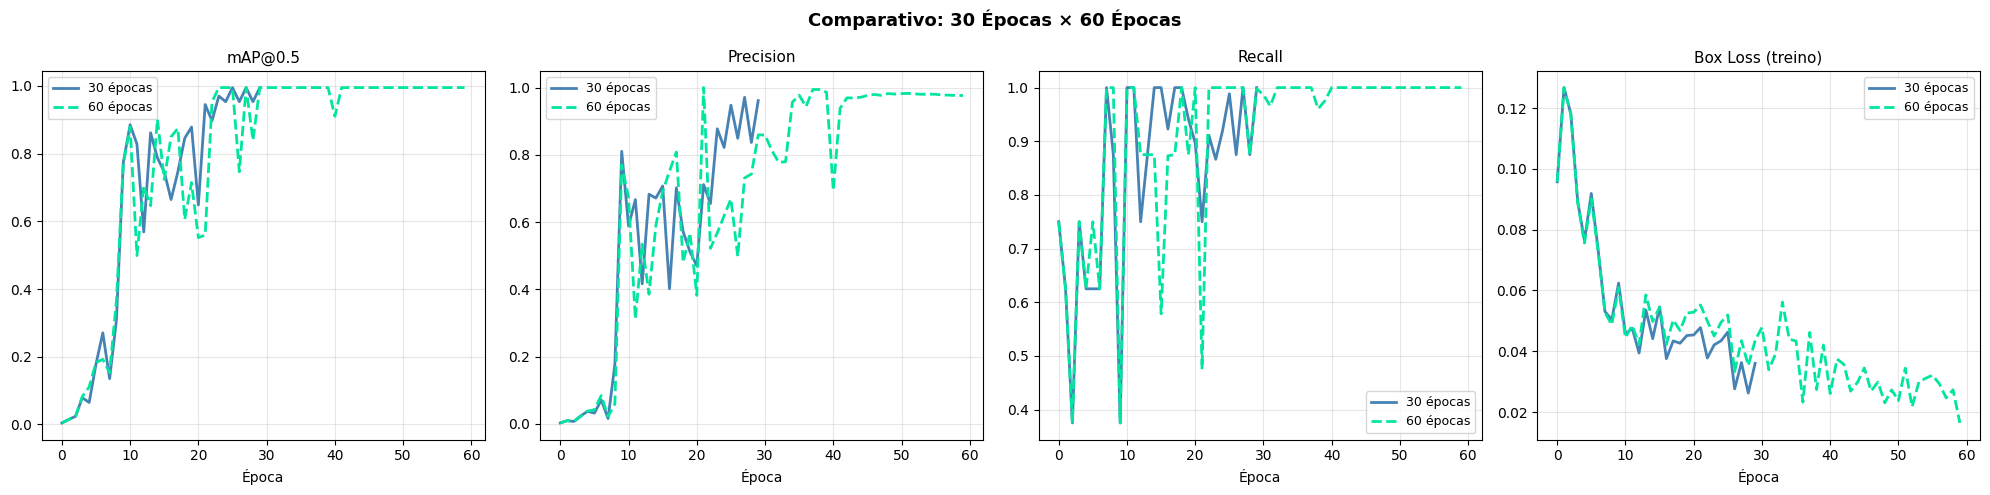

✅ Gráfico comparativo salvo no Drive.


In [18]:
# Gráfico comparativo lado a lado — 30 vs 60 épocas
import pandas as pd
import matplotlib.pyplot as plt
import shutil, os

def carregar(path):
    if not os.path.exists(path): return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df

df30 = carregar('/content/yolov5/runs/train/exp_30ep/results.csv')
df60 = carregar('/content/yolov5/runs/train/exp_60ep/results.csv')

if df30 is not None and df60 is not None:
    pares = [
        ('metrics/mAP_0.5',    'mAP@0.5'),
        ('metrics/precision',  'Precision'),
        ('metrics/recall',     'Recall'),
        ('train/box_loss',     'Box Loss (treino)'),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('Comparativo: 30 Épocas × 60 Épocas', fontsize=13, fontweight='bold')

    for ax, (col, titulo) in zip(axes, pares):
        if col in df30.columns and col in df60.columns:
            ax.plot(df30[col], label='30 épocas', color='steelblue', linewidth=2)
            ax.plot(df60[col], label='60 épocas', color='#00e5a0',
                    linewidth=2, linestyle='--')
            ax.set_title(titulo, fontsize=11)
            ax.set_xlabel('Época')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'{col}\nnão encontrado',
                    ha='center', va='center', transform=ax.transAxes, color='gray')

    plt.tight_layout()
    local_path = '/content/comparativo_epocas.png'
    plt.savefig(local_path, dpi=120, bbox_inches='tight')
    shutil.copy(local_path, os.path.join(DRIVE_BASE, 'comparativo_epocas.png'))
    plt.show()
    print("✅ Gráfico comparativo salvo no Drive.")
else:
    print("⚠️  DataFrames não carregados — execute os treinamentos primeiro.")



🔲 Confusion Matrix — 30 Épocas:


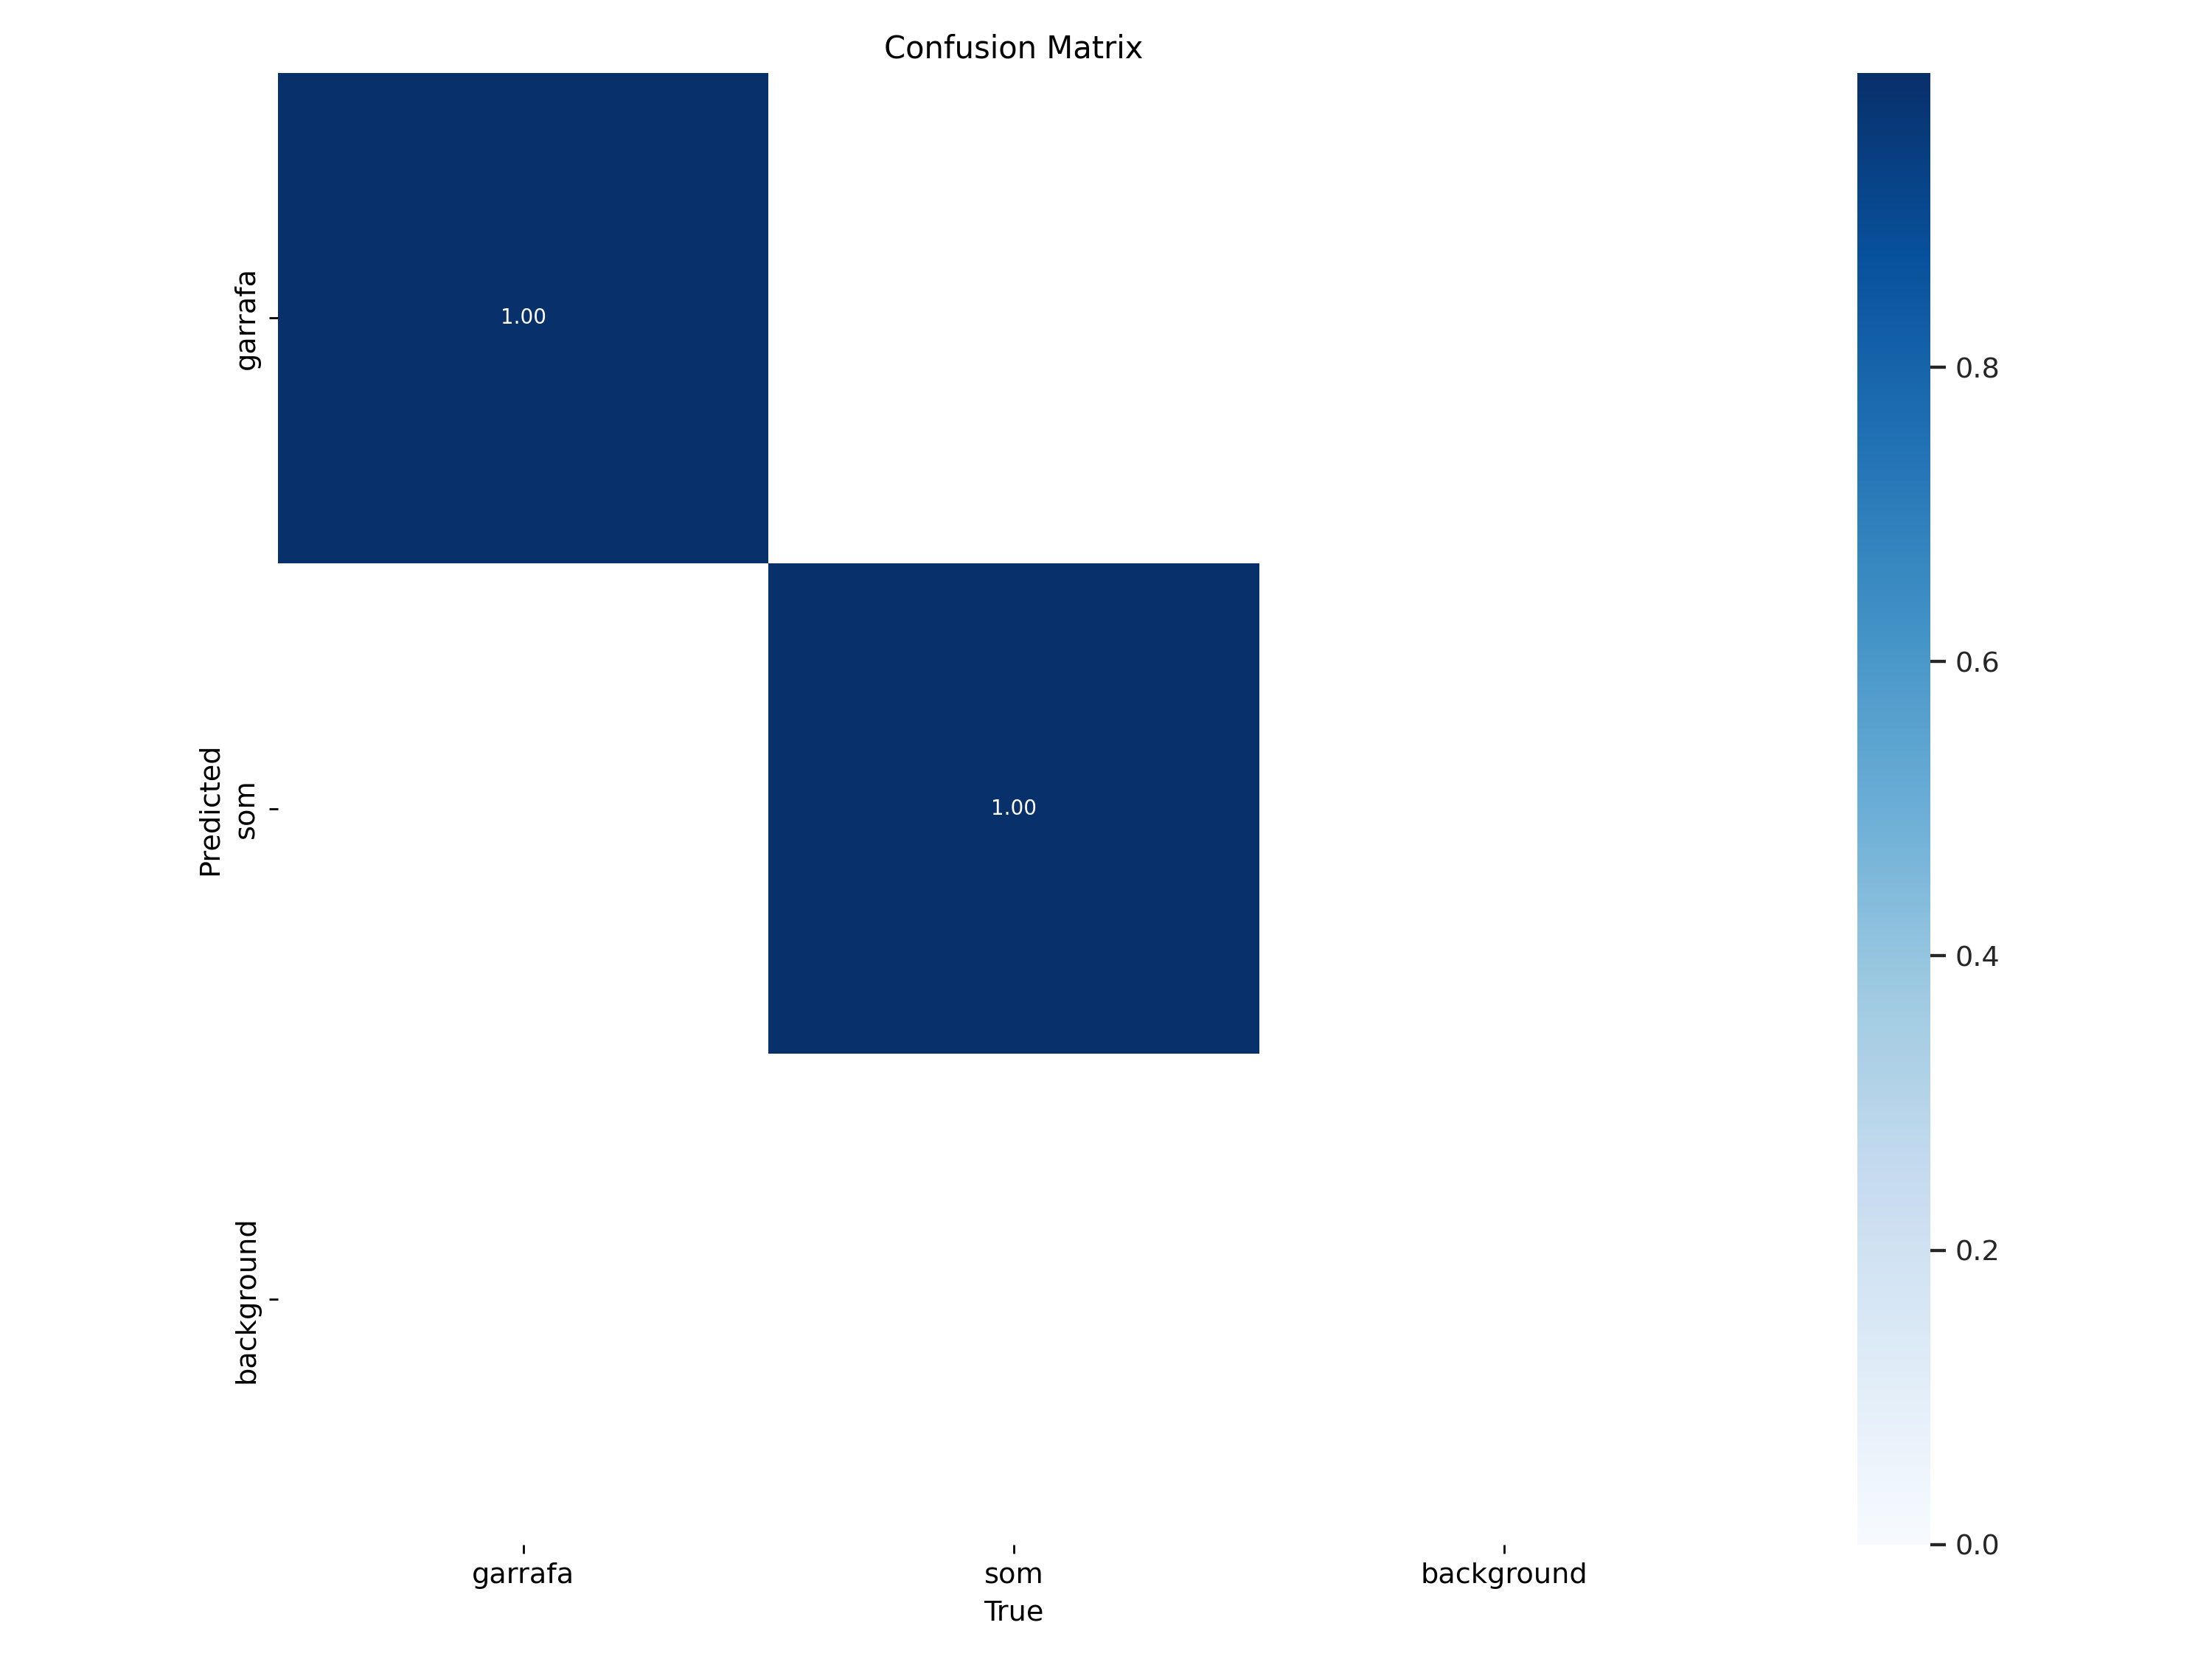


🔲 Confusion Matrix — 60 Épocas:


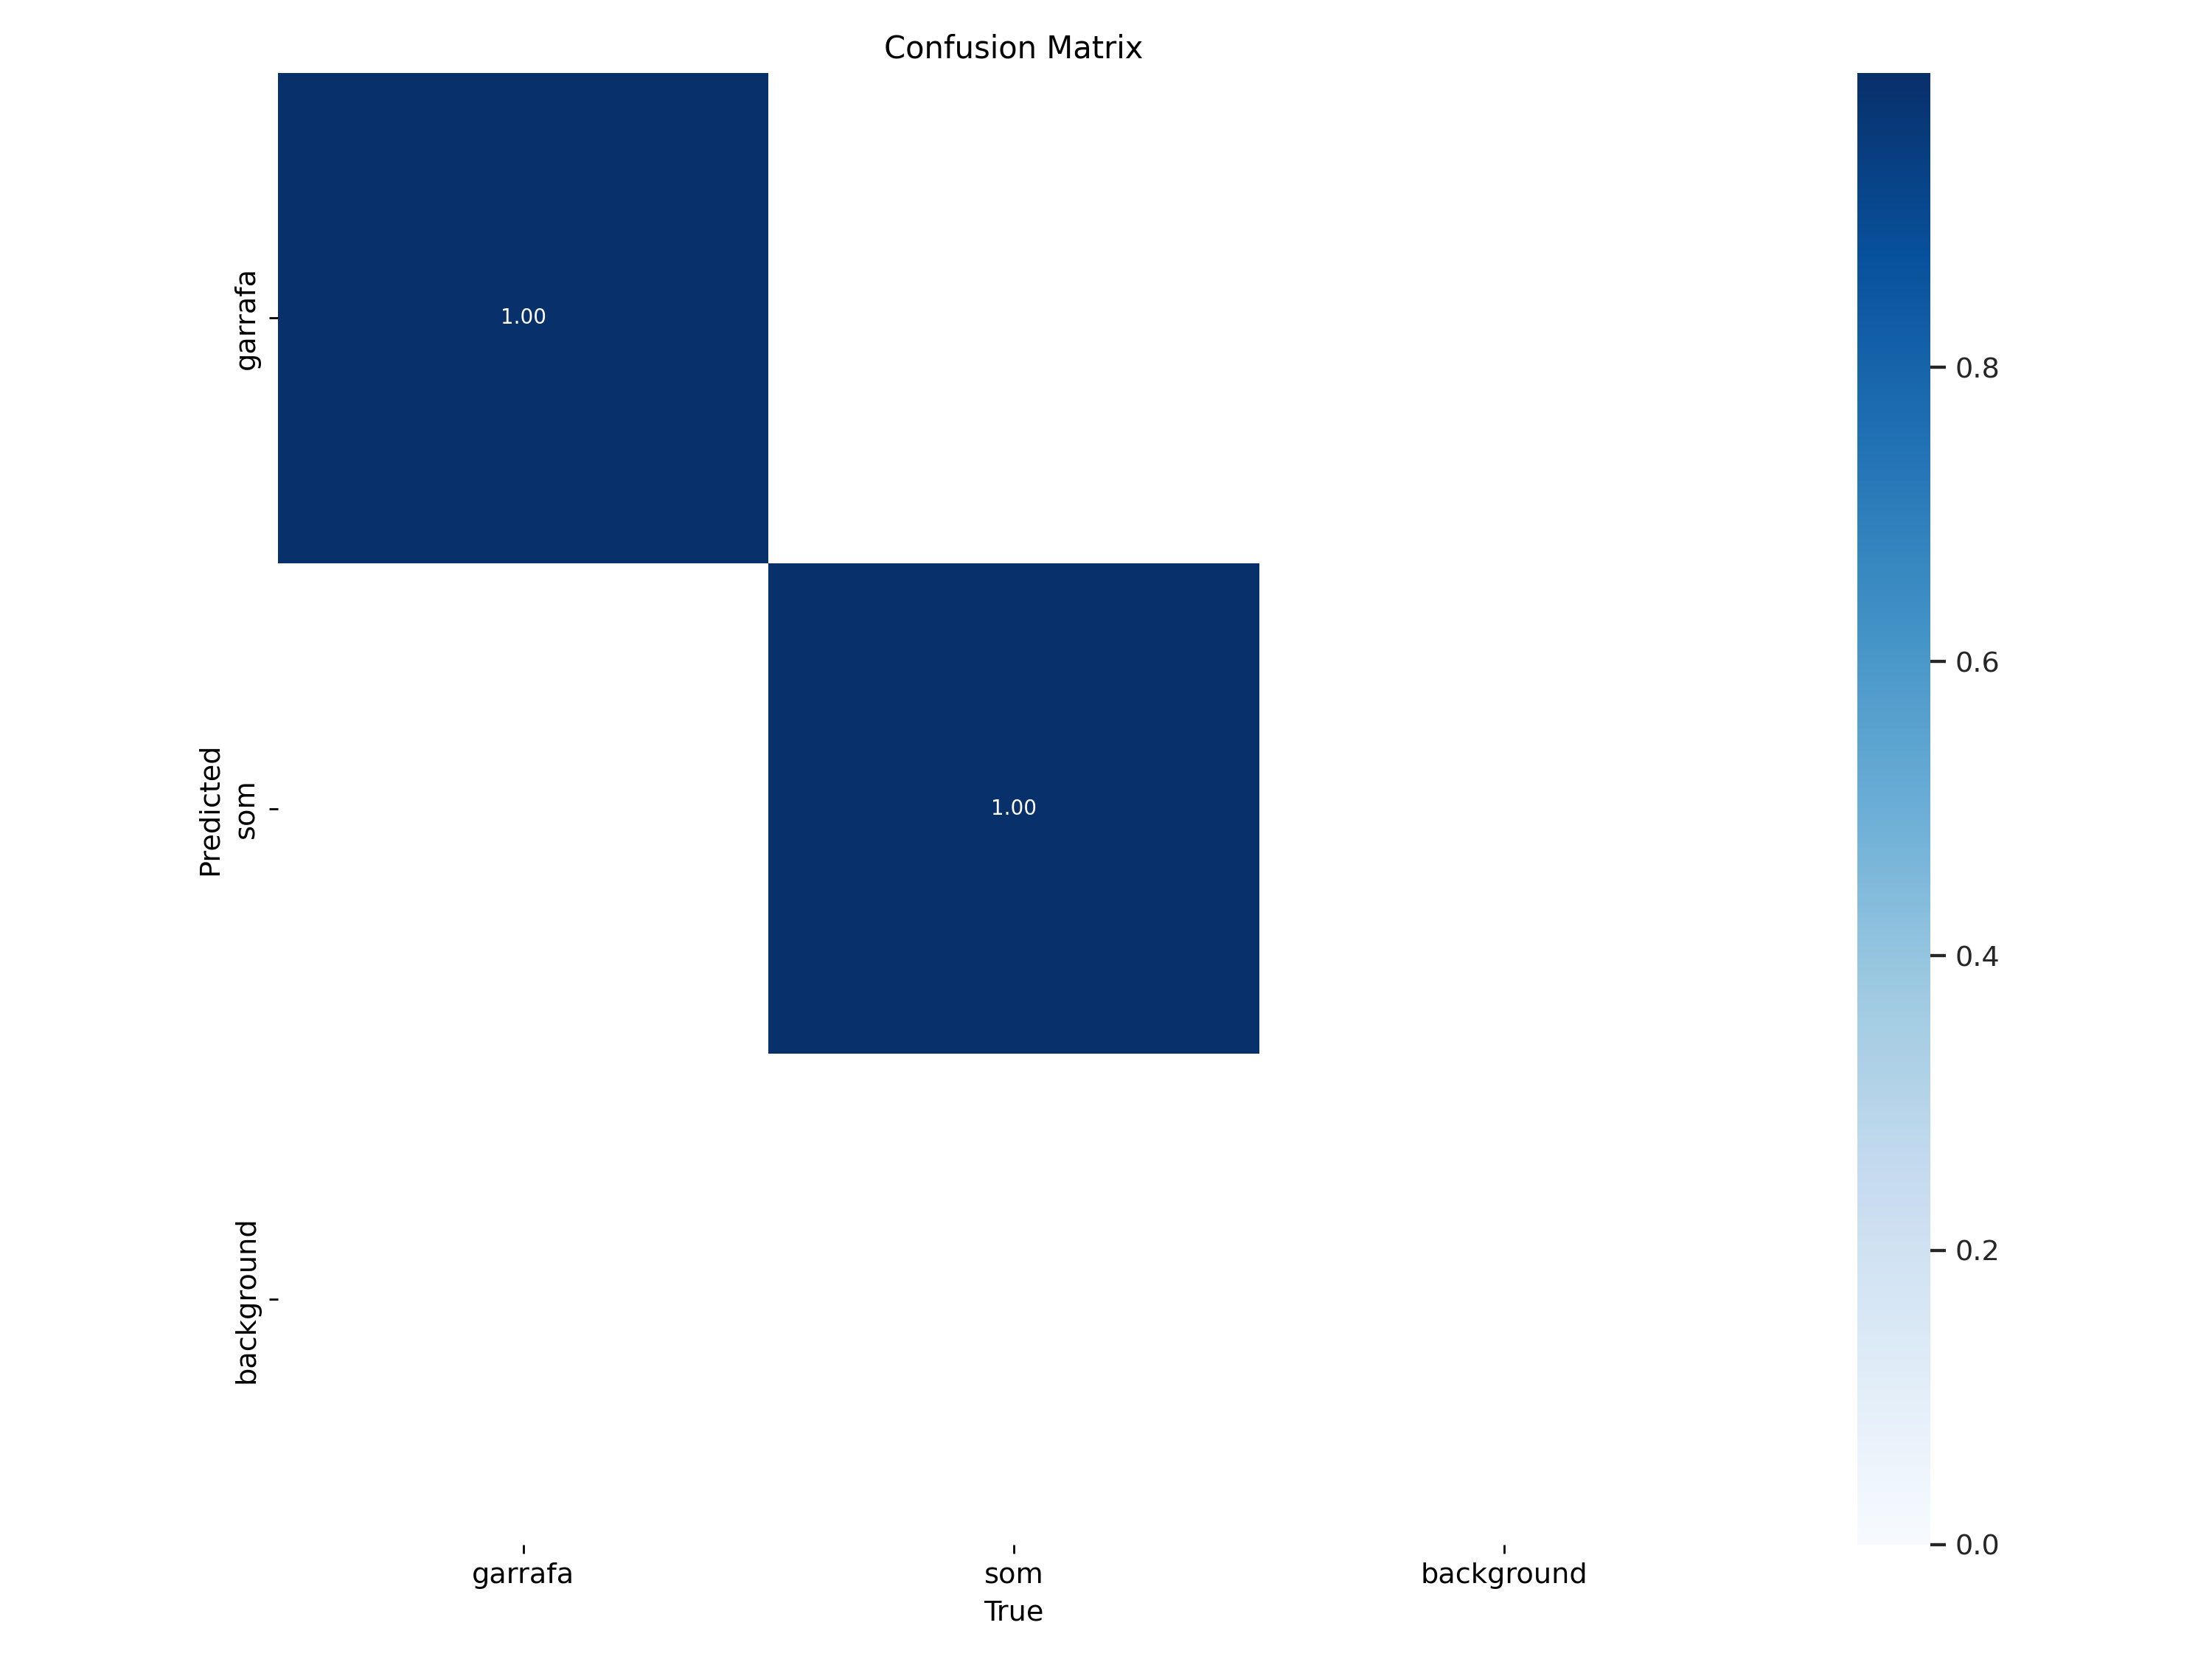

In [19]:
# Exibir confusion matrix de cada modelo para análise de erros por classe
from IPython.display import Image, display
import os

for exp, label in [('exp_30ep', '30 Épocas'), ('exp_60ep', '60 Épocas')]:
    path = f'/content/yolov5/runs/train/{exp}/confusion_matrix.png'
    if os.path.exists(path):
        print(f"\n🔲 Confusion Matrix — {label}:")
        display(Image(path, width=550))
    else:
        print(f"⚠️  Confusion matrix não encontrada para {label}")


---
## 10. Inferência nas Imagens de Teste <a id='10'></a>

Aplicamos os melhores pesos de cada treinamento (`best.pt`) nas **8 imagens de teste**
— imagens que o modelo **nunca viu** durante treino ou validação.

O parâmetro `--conf 0.25` define o limiar de confiança mínimo para exibir uma detecção.


In [20]:
# Verificar se os pesos best.pt foram gerados em ambos os treinos
import os

for exp in ['exp_30ep', 'exp_60ep']:
    path = f'/content/yolov5/runs/train/{exp}/weights/best.pt'
    status = "✅ encontrado" if os.path.exists(path) else "❌ NÃO encontrado"
    print(f"{exp}/weights/best.pt → {status}")


exp_30ep/weights/best.pt → ✅ encontrado
exp_60ep/weights/best.pt → ✅ encontrado


In [21]:
# ── INFERÊNCIA: modelo de 30 épocas ─────────────────────────────────────────
import subprocess, os

os.chdir('/content/yolov5')

TEST_PATH = os.path.join(DRIVE_BASE, 'dataset', 'images', 'test')
print(f"📂 Imagens de teste: {TEST_PATH}")
print(f"   Existem: {os.path.exists(TEST_PATH)}")
print(f"   Arquivos: {os.listdir(TEST_PATH) if os.path.exists(TEST_PATH) else 'N/A'}")
print()

result = subprocess.run(
    [
        'python', 'detect.py',
        '--weights', 'runs/train/exp_30ep/weights/best.pt',
        '--source',  TEST_PATH,   # lista de args → sem problemas com espaços
        '--img',     '640',
        '--conf',    '0.25',
        '--name',    'detect_30ep',
        '--exist-ok'
    ],
    capture_output=True, text=True
)

print(result.stdout[-2000:])
if result.stderr:
    print("STDERR:", result.stderr[-300:])

if result.returncode == 0:
    print("\n✅ Inferência 30 épocas concluída!")
    print("📁 Resultados em: runs/detect/detect_30ep/")
else:
    print(f"\n❌ Erro (código {result.returncode})")


📂 Imagens de teste: /content/drive/MyDrive/projeto_fase6/dataset/images/test
   Existem: True
   Arquivos: ['Garrafa_33.jpg', 'Garrafa_35.jpg', 'Garrafa_36.jpg', 'Garrafa_34.jpg', 'Som_33.jpg', 'Som_34.jpg', 'Som_35.jpg', 'Som_36.jpg']


STDERR: _fase6/dataset/images/test/Som_35.jpg: 640x480 1 som, 9.3ms
image 8/8 /content/drive/MyDrive/projeto_fase6/dataset/images/test/Som_36.jpg: 640x480 1 som, 8.6ms
Speed: 0.7ms pre-process, 12.6ms inference, 20.5ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/detect_30ep


✅ Inferência 30 épocas concluída!
📁 Resultados em: runs/detect/detect_30ep/


In [22]:
# ── INFERÊNCIA: modelo de 60 épocas ─────────────────────────────────────────
import subprocess, os

result = subprocess.run(
    [
        'python', 'detect.py',
        '--weights', 'runs/train/exp_60ep/weights/best.pt',
        '--source',  TEST_PATH,
        '--img',     '640',
        '--conf',    '0.25',
        '--name',    'detect_60ep',
        '--exist-ok'
    ],
    capture_output=True, text=True
)

print(result.stdout[-2000:])
if result.stderr:
    print("STDERR:", result.stderr[-300:])

if result.returncode == 0:
    print("\n✅ Inferência 60 épocas concluída!")
    print("📁 Resultados em: runs/detect/detect_60ep/")
else:
    print(f"\n❌ Erro (código {result.returncode})")



STDERR: _fase6/dataset/images/test/Som_35.jpg: 640x480 1 som, 8.6ms
image 8/8 /content/drive/MyDrive/projeto_fase6/dataset/images/test/Som_36.jpg: 640x480 1 som, 8.6ms
Speed: 0.6ms pre-process, 12.2ms inference, 16.3ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/detect_60ep


✅ Inferência 60 épocas concluída!
📁 Resultados em: runs/detect/detect_60ep/


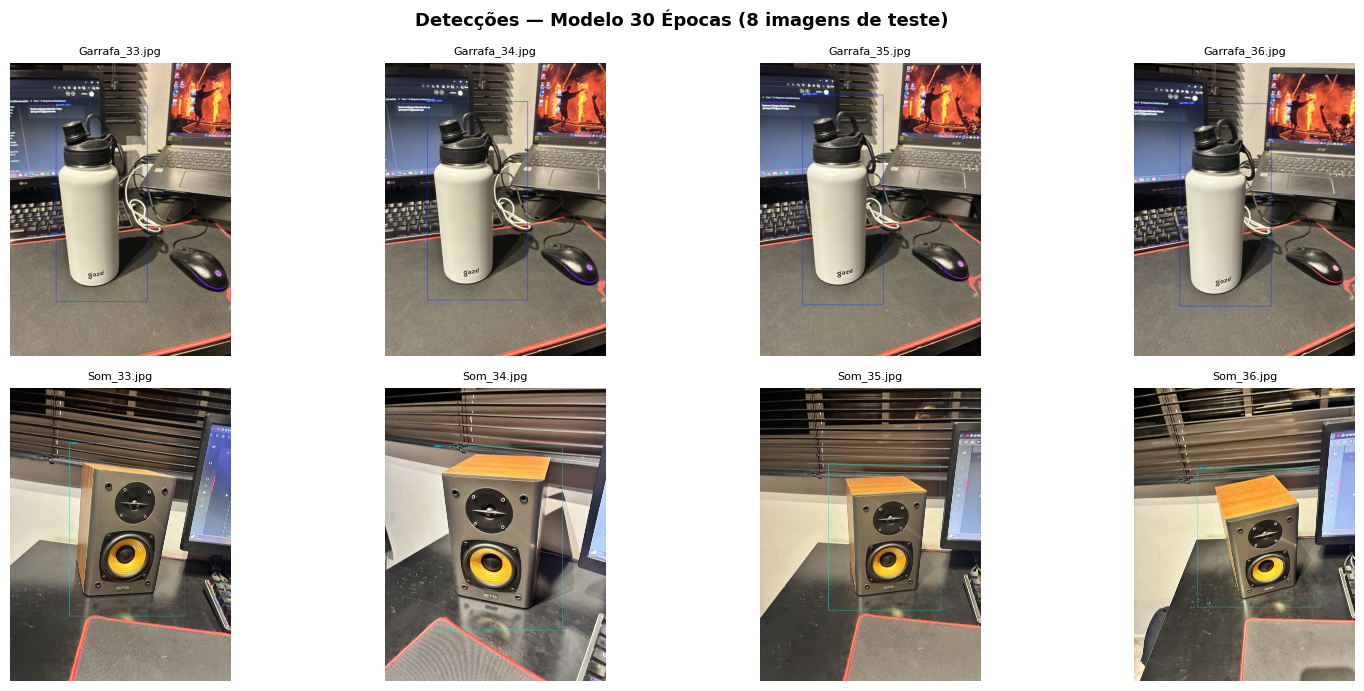

✅ 8 imagens processadas. Salvo em: /content/drive/MyDrive/projeto_fase6/deteccoes_30ep.png


In [23]:
# Exibir imagens de teste processadas — 30 épocas
import os, shutil, random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def exibir_deteccoes(detect_dir, label, drive_filename):
    if not os.path.exists(detect_dir):
        print(f"❌ Diretório não encontrado: {detect_dir}")
        return

    imgs = sorted([f for f in os.listdir(detect_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    n = len(imgs)

    if n == 0:
        print("⚠️  Nenhuma imagem encontrada na pasta de detecção.")
        return

    cols = min(4, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    fig.suptitle(f'Detecções — {label} ({n} imagens de teste)',
                 fontsize=13, fontweight='bold')

    # Normalizar axes para lista 2D em qualquer combinação de rows/cols
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [list(axes)]
    else:
        axes = [list(row) for row in axes]

    for i, fname in enumerate(imgs):
        r, c = divmod(i, cols)
        img = mpimg.imread(os.path.join(detect_dir, fname))
        axes[r][c].imshow(img)
        axes[r][c].set_title(fname, fontsize=8)
        axes[r][c].axis('off')

    # Ocultar eixos extras
    for i in range(n, rows * cols):
        r, c = divmod(i, cols)
        axes[r][c].axis('off')

    plt.tight_layout()

    # Salvar localmente e copiar para o Drive (evita erro com espaços no path)
    local_path = f'/content/{drive_filename}'
    drive_path = os.path.join(DRIVE_BASE, drive_filename)
    plt.savefig(local_path, dpi=100, bbox_inches='tight')
    shutil.copy(local_path, drive_path)
    plt.show()
    print(f"✅ {n} imagens processadas. Salvo em: {drive_path}")

# Exibir resultados das 30 épocas
exibir_deteccoes(
    detect_dir     = '/content/yolov5/runs/detect/detect_30ep',
    label          = 'Modelo 30 Épocas',
    drive_filename = 'deteccoes_30ep.png'
)


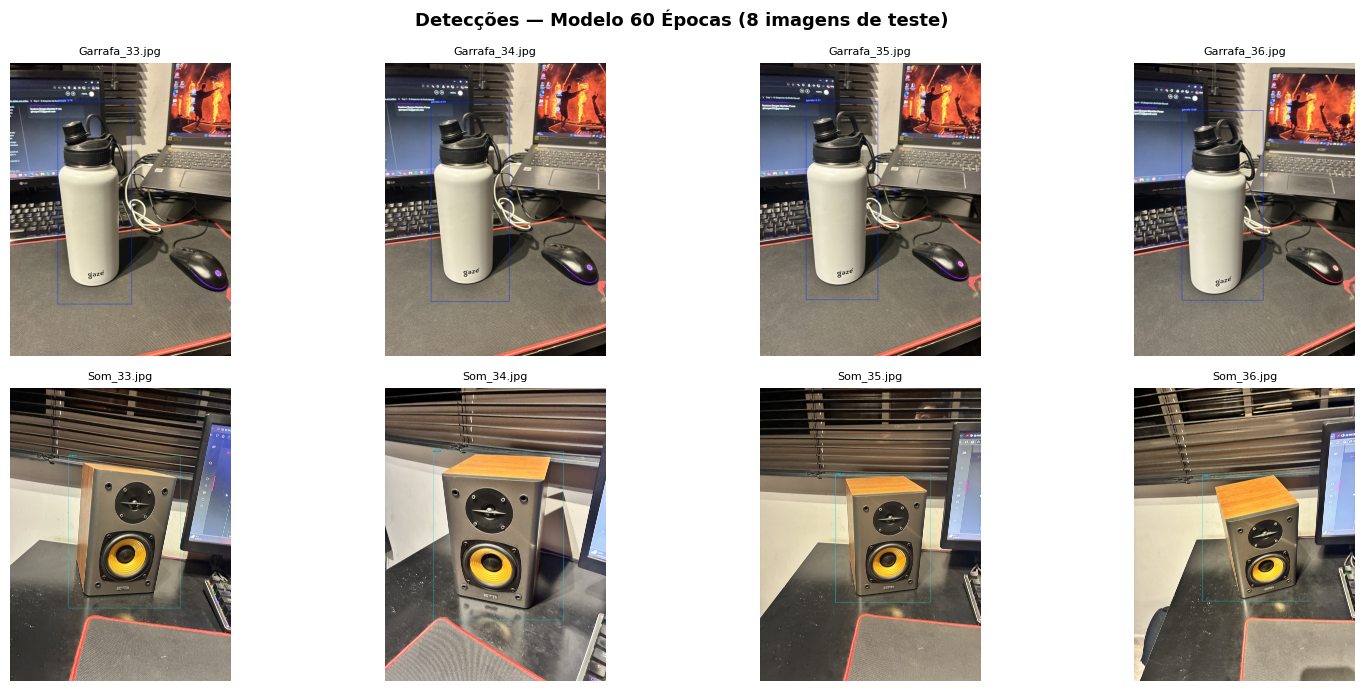

✅ 8 imagens processadas. Salvo em: /content/drive/MyDrive/projeto_fase6/deteccoes_60ep.png


In [24]:
# Exibir imagens de teste processadas — 60 épocas
exibir_deteccoes(
    detect_dir     = '/content/yolov5/runs/detect/detect_60ep',
    label          = 'Modelo 60 Épocas',
    drive_filename = 'deteccoes_60ep.png'
)


In [25]:
# Copiar toda a pasta runs/ para o Google Drive (persistência dos resultados)
import shutil, os

pares = [
    ('/content/yolov5/runs/train/exp_30ep',     os.path.join(DRIVE_BASE, 'results', 'train_30ep')),
    ('/content/yolov5/runs/train/exp_60ep',     os.path.join(DRIVE_BASE, 'results', 'train_60ep')),
    ('/content/yolov5/runs/detect/detect_30ep', os.path.join(DRIVE_BASE, 'results', 'detect_30ep')),
    ('/content/yolov5/runs/detect/detect_60ep', os.path.join(DRIVE_BASE, 'results', 'detect_60ep')),
]

for src, dst in pares:
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f"✅ {os.path.basename(src):20s} → Drive")
    else:
        print(f"⚠️  Não encontrado: {src}")

print("\n✅ Todos os resultados copiados para o Drive!")


✅ exp_30ep             → Drive
✅ exp_60ep             → Drive
✅ detect_30ep          → Drive
✅ detect_60ep          → Drive

✅ Todos os resultados copiados para o Drive!


---
## 11. Conclusões <a id='11'></a>

> **Instrução:** preencha esta seção com os valores reais obtidos após a execução.
> Use o **Modelo de Conclusões** (arquivo HTML entregue junto ao projeto) para
> gerar o texto automaticamente e cole aqui.

---

### 11.1 Sobre o Dataset e as Classes

O experimento utilizou um dataset customizado com **80 imagens**, divididas igualmente
entre as classes **Garrafa** e **Som**. A divisão seguiu o padrão 80/10/10
(treino/validação/teste). As imagens foram rotuladas manualmente com bounding boxes
no Make Sense IA e exportadas no formato YOLO.

---

### 11.2 Comparativo: 30 Épocas × 60 Épocas

| Métrica | 30 Épocas | 60 Épocas | Δ (60 − 30) | Melhor |
|---------|-----------|-----------|-------------|--------|
| mAP@0.5 | _%_ | _%_ | _pp_ | — |
| mAP@0.5:0.95 | _%_ | _%_ | _pp_ | — |
| Precision | _%_ | _%_ | _pp_ | — |
| Recall | _%_ | _%_ | _pp_ | — |
| Box Loss | — | — | — | — |
| Tempo de treino | _min_ | _min_ | _min_ | — |

_(Preencha a tabela acima com os valores do comparativo gerado na Seção 9)_

**Análise:** _(descreva aqui se a melhora de X pontos no mAP justificou o dobro
de tempo de treinamento, e qual configuração você recomendaria para este dataset)_

---

### 11.3 Análise Visual das Detecções

**30 épocas:** _(descreva o que você observou nos prints — quantas detecções
corretas, boxes imprecisos, falsos positivos, etc.)_

**60 épocas:** _(idem para 60 épocas — houve melhora visual nos boxes?
O modelo cometeu menos erros de classificação?)_

**Distinção entre classes:** _(o modelo conseguiu separar Garrafa de Som
consistentemente? Em quais condições teve mais dificuldade?)_

---


- FIAP (2025). *Fase 6 — Cognitive Computing & Computer Vision.*

---
<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Fiap-logo-novo.jpg" width="80"/>
  <br><em>FarmTech Solutions · FIAP Fase 6 · 2025</em>
</p>
